# Handling Missing Data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadtalhaishtiaq/ai-orchestrator/blob/main/01-data-preprocessing/01_handling_missing_data.ipynb)

**Time**: ~20 minutes

## What You'll Learn
- Why missing data breaks ML models
- How to detect missing values
- Strategies: Drop, Mean/Median, Forward Fill, KNN
- When to use which strategy

## Why This Matters

Real data is messy. 80% of data science is cleaning. Missing values are the #1 issue.

**Example:** Customer database with missing ages:
```
Name    Age    Income
John    25     50000
Sara    NaN    60000  ← ML models can't handle NaN!
Mike    30     NaN
```

You can't train a model until you fix this.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer

np.random.seed(42)
print("Handling Missing Data: The Most Common Preprocessing Task")

Handling Missing Data: The Most Common Preprocessing Task


---
## 1. Create Data with Missing Values

In [2]:
# Realistic dataset: employee data
data = {
    'employee_id': range(1, 21),
    'age': [25, 30, np.nan, 28, 35, np.nan, 40, 22, np.nan, 27,
            33, 29, np.nan, 38, 26, 31, 24, np.nan, 36, 32],
    'salary': [50000, 60000, 55000, np.nan, 70000, 65000, np.nan, 45000, 58000, 52000,
               np.nan, 61000, 67000, np.nan, 48000, 63000, 46000, 69000, np.nan, 64000],
    'years_experience': [2, 5, 3, np.nan, 8, 6, np.nan, 1, 4, 3,
                        7, 5, np.nan, 10, 2, 6, 1, np.nan, 9, 7],
    'department': ['IT', 'HR', 'IT', 'Sales', 'IT', None, 'HR', 'Sales', 'IT', 'HR',
                  'Sales', 'IT', None, 'HR', 'Sales', 'IT', 'HR', 'Sales', None, 'IT']
}

df = pd.DataFrame(data)
print("Employee Dataset:")
print(df.head(10))
print(f"\nDataset shape: {df.shape}")

Employee Dataset:
   employee_id   age   salary  years_experience department
0            1  25.0  50000.0               2.0         IT
1            2  30.0  60000.0               5.0         HR
2            3   NaN  55000.0               3.0         IT
3            4  28.0      NaN               NaN      Sales
4            5  35.0  70000.0               8.0         IT
5            6   NaN  65000.0               6.0       None
6            7  40.0      NaN               NaN         HR
7            8  22.0  45000.0               1.0      Sales
8            9   NaN  58000.0               4.0         IT
9           10  27.0  52000.0               3.0         HR

Dataset shape: (20, 5)


---
## 2. Detect Missing Values

In [3]:
# Check missing values
print("Missing Value Summary:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"\nPercentage of missing data:")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing Value Summary:
employee_id         0
age                 5
salary              5
years_experience    4
department          3
dtype: int64

Total missing values: 17

Percentage of missing data:
employee_id          0.0
age                 25.0
salary              25.0
years_experience    20.0
department          15.0
dtype: float64


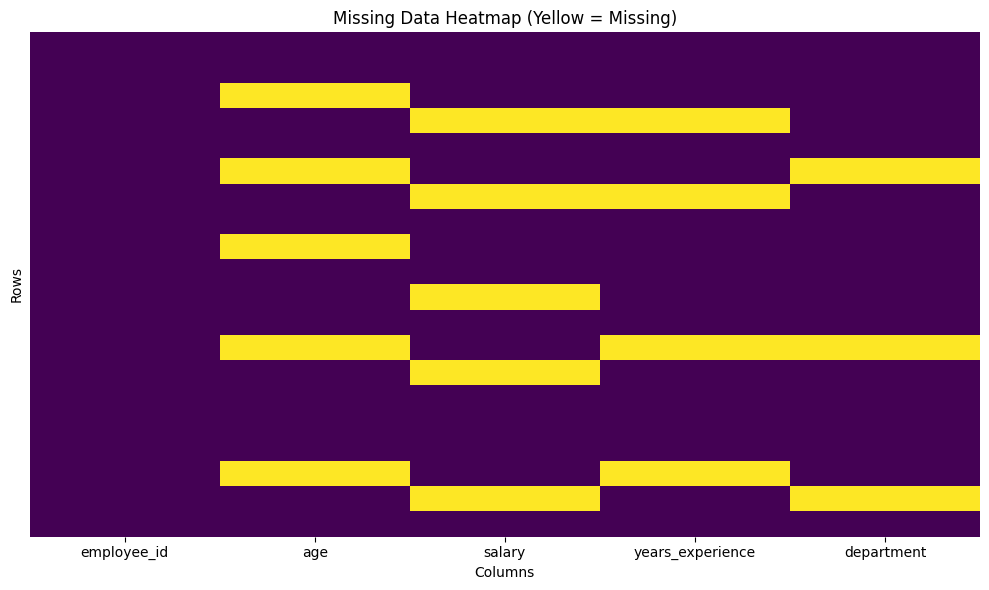

Yellow bars = missing values
This helps you see patterns: random missing vs systematic


In [4]:
# Visualize missing data
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Data Heatmap (Yellow = Missing)')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()

print("Yellow bars = missing values")
print("This helps you see patterns: random missing vs systematic")

---
## 3. Strategy 1: Drop Missing Values

In [5]:
# Option A: Drop rows with ANY missing value
df_drop_rows = df.dropna()
print(f"Original: {len(df)} rows")
print(f"After dropping rows: {len(df_drop_rows)} rows")
print(f"Lost: {len(df) - len(df_drop_rows)} rows ({(len(df) - len(df_drop_rows))/len(df)*100:.1f}%)")

print("\n⚠️ CAUTION: Dropped too much data!")
print("Use dropna() only when <5% rows have missing values")

Original: 20 rows
After dropping rows: 10 rows
Lost: 10 rows (50.0%)

⚠️ CAUTION: Dropped too much data!
Use dropna() only when <5% rows have missing values


In [6]:
# Option B: Drop columns with missing values
df_drop_cols = df.dropna(axis=1)
print(f"Original: {df.shape[1]} columns")
print(f"After dropping columns: {df_drop_cols.shape[1]} columns")
print(f"\nRemaining columns: {list(df_drop_cols.columns)}")

print("\n⚠️ Lost important features! Usually a bad idea.")

Original: 5 columns
After dropping columns: 1 columns

Remaining columns: ['employee_id']

⚠️ Lost important features! Usually a bad idea.


---
## 4. Strategy 2: Mean/Median Imputation

In [7]:
# Mean imputation for numerical columns
df_mean = df.copy()

# Fill with mean
df_mean['age'].fillna(df_mean['age'].mean(), inplace=True)
df_mean['salary'].fillna(df_mean['salary'].mean(), inplace=True)
df_mean['years_experience'].fillna(df_mean['years_experience'].mean(), inplace=True)

print("Mean Imputation:")
print(df_mean[['age', 'salary', 'years_experience']].describe().loc[['mean']])
print(f"\nMissing values after imputation: {df_mean.isnull().sum().sum()}")

Mean Imputation:
       age   salary  years_experience
mean  30.4  58200.0            4.9375

Missing values after imputation: 3


/tmp/ipython-input-2846920433.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mean['age'].fillna(df_mean['age'].mean(), inplace=True)
/tmp/ipython-input-2846920433.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [8]:
# Median imputation (better for skewed data)
df_median = df.copy()

imputer = SimpleImputer(strategy='median')
df_median[['age', 'salary', 'years_experience']] = imputer.fit_transform(
    df_median[['age', 'salary', 'years_experience']]
)

print("Median Imputation:")
print(df_median[['age', 'salary', 'years_experience']].describe().loc[['50%']])

print("\n✅ USE MEDIAN when data is skewed (outliers present)")
print("✅ USE MEAN when data is normally distributed")

Median Imputation:
      age   salary  years_experience
50%  30.0  60000.0               5.0

✅ USE MEDIAN when data is skewed (outliers present)
✅ USE MEAN when data is normally distributed


---
## 5. Strategy 3: Mode (for Categorical Data)

In [9]:
# Mode imputation for categorical columns
df_mode = df.copy()

# Most frequent value
most_frequent_dept = df_mode['department'].mode()[0]
df_mode['department'].fillna(most_frequent_dept, inplace=True)

print(f"Most frequent department: {most_frequent_dept}")
print(f"\nDepartment distribution after imputation:")
print(df_mode['department'].value_counts())

print("\n✅ USE MODE for categorical data (department, country, etc.)")

Most frequent department: IT

Department distribution after imputation:
department
IT       10
HR        5
Sales     5
Name: count, dtype: int64

✅ USE MODE for categorical data (department, country, etc.)


/tmp/ipython-input-2977313345.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mode['department'].fillna(most_frequent_dept, inplace=True)


---
## 6. Strategy 4: Forward/Backward Fill

In [10]:
# Forward fill: use previous value
df_ffill = df.copy()
df_ffill['age'].fillna(method='ffill', inplace=True)

print("Forward Fill Example:")
print("Before:")
print(df[['employee_id', 'age']].head(10))
print("\nAfter:")
print(df_ffill[['employee_id', 'age']].head(10))

print("\n✅ USE FORWARD FILL for time series data (stock prices, weather)")
print("❌ DON'T USE for random missing data")

Forward Fill Example:
Before:
   employee_id   age
0            1  25.0
1            2  30.0
2            3   NaN
3            4  28.0
4            5  35.0
5            6   NaN
6            7  40.0
7            8  22.0
8            9   NaN
9           10  27.0

After:
   employee_id   age
0            1  25.0
1            2  30.0
2            3  30.0
3            4  28.0
4            5  35.0
5            6  35.0
6            7  40.0
7            8  22.0
8            9  22.0
9           10  27.0

✅ USE FORWARD FILL for time series data (stock prices, weather)
❌ DON'T USE for random missing data


/tmp/ipython-input-1958315330.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ffill['age'].fillna(method='ffill', inplace=True)
/tmp/ipython-input-1958315330.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill['age'].fillna(method='ffill', inplace=True)


---
## 7. Strategy 5: KNN Imputation (Advanced)

In [11]:
# KNN: Use similar rows to fill missing values
df_knn = df.copy()

knn_imputer = KNNImputer(n_neighbors=3)
df_knn[['age', 'salary', 'years_experience']] = knn_imputer.fit_transform(
    df_knn[['age', 'salary', 'years_experience']]
)

print("KNN Imputation (uses 3 nearest neighbors):")
print(df_knn[['age', 'salary', 'years_experience']].head(10))

print("\n✅ KNN is SMART: fills based on similar rows")
print("✅ More accurate than mean/median")
print("❌ Slower for large datasets")

KNN Imputation (uses 3 nearest neighbors):
         age        salary  years_experience
0  25.000000  50000.000000          2.000000
1  30.000000  60000.000000          5.000000
2  35.666667  55000.000000          3.000000
3  28.000000  57666.666667          4.333333
4  35.000000  70000.000000          8.000000
5  35.666667  65000.000000          6.000000
6  40.000000  65666.666667          9.000000
7  22.000000  45000.000000          1.000000
8  35.666667  58000.000000          4.000000
9  27.000000  52000.000000          3.000000

✅ KNN is SMART: fills based on similar rows
✅ More accurate than mean/median
❌ Slower for large datasets


---
## 8. Compare All Strategies

In [12]:
# Compare results
comparison = pd.DataFrame({
    'Strategy': ['Original', 'Drop Rows', 'Mean', 'Median', 'KNN'],
    'Rows': [len(df), len(df_drop_rows), len(df_mean), len(df_median), len(df_knn)],
    'Missing': [df.isnull().sum().sum(), 
                df_drop_rows.isnull().sum().sum(),
                df_mean.isnull().sum().sum(),
                df_median.isnull().sum().sum(),
                df_knn.isnull().sum().sum()],
    'Avg Age': [df['age'].mean(), 
                df_drop_rows['age'].mean(),
                df_mean['age'].mean(),
                df_median['age'].mean(),
                df_knn['age'].mean()]
})

print(comparison)

print("\n📊 Key Insights:")
print("  - Drop rows: Lost data, but cleanest")
print("  - Mean/Median: Quick, good for simple cases")
print("  - KNN: Most accurate, but slower")

    Strategy  Rows  Missing    Avg Age
0   Original    20       17  30.400000
1  Drop Rows    10        0  28.100000
2       Mean    20        3  30.400000
3     Median    20        3  30.300000
4        KNN    20        3  31.416667

📊 Key Insights:
  - Drop rows: Lost data, but cleanest
  - Mean/Median: Quick, good for simple cases
  - KNN: Most accurate, but slower


---
## Decision Tree: Which Strategy?

```
Is data < 5% missing?
  YES → Drop rows (simplest)
  NO  → Continue

Is it time series data?
  YES → Forward/Backward Fill
  NO  → Continue

Is it categorical?
  YES → Mode (most frequent)
  NO  → Continue

Is data skewed (outliers)?
  YES → Median
  NO  → Mean or KNN

Need high accuracy?
  YES → KNN
  NO  → Mean/Median
```

---
## Key Takeaways

1. **Always check** for missing data first (`df.isnull().sum()`)
2. **Drop** only if <5% missing
3. **Mean/Median** for quick fixes
4. **Mode** for categorical data
5. **Forward fill** for time series
6. **KNN** for best accuracy (but slower)

**Most common in practice**: Median imputation (simple + robust)

---
## Your Turn

1. Load your own dataset with missing values
2. Visualize the missing data pattern
3. Try 3 different imputation strategies
4. Compare results - which works best?

In [13]:
# Your code here